
# **Customer Churn Prediction Using Machine Learning**

Author: Perpetua Okoloekwe

Day 23/90 AI Engineering Project


## Business Problem

Customer churn is a major challenge for telecom companies.
Losing customers directly impacts revenue and growth.

The goal of this project is to identify factors associated with churn and build machine learning models that predict which customers are likely to leave.

In [1]:
# Import Labraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## Load Dataset

In [5]:
df = pd.read_csv("TelcoCustomerChurn.csv")

df.head()

,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


## Exploratory Data Analysis (EDA)

In this section, we investigate the dataset structure, data types, missing values, and target distribution.

In [6]:
df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   f

,Age,NumberofDependents,ZipCode,Latitude,Longitude,Population,Number_of_Referrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,ChurnScore,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [7]:
df.shape

(7043, 50)

In [8]:
df["ChurnLabel"].value_counts()

,count
ChurnLabel,
No,5174
Yes,1869


In [10]:
df["ChurnLabel"].value_counts(normalize=True) * 100

,proportion
ChurnLabel,
No,73.463013
Yes,26.536987


The dataset contains 7,043 customers.

The target variable (ChurnLabel) is moderately imbalanced:

- No Churn: 5,174
- Churn: 1,869

# **Target Distribution Plot**

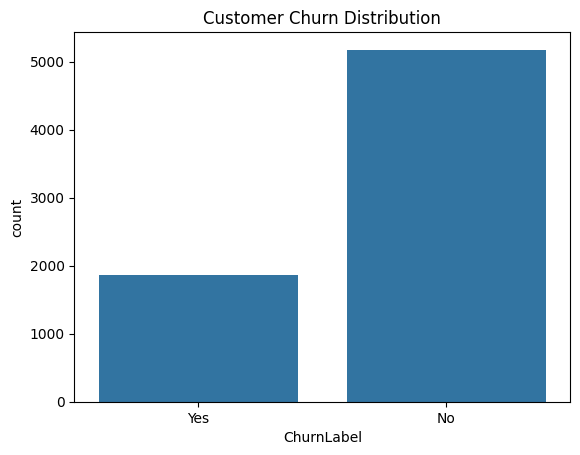

In [14]:
sns.countplot(
    x="ChurnLabel",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()


## Missing Value Investigation

Not all missing values represent missing data.

Some missing values contain business meaning and were investigated before treatment.

In [9]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Under30,0
SeniorCitizen,0
Married,0
Dependents,0
NumberofDependents,0
Country,0
State,0


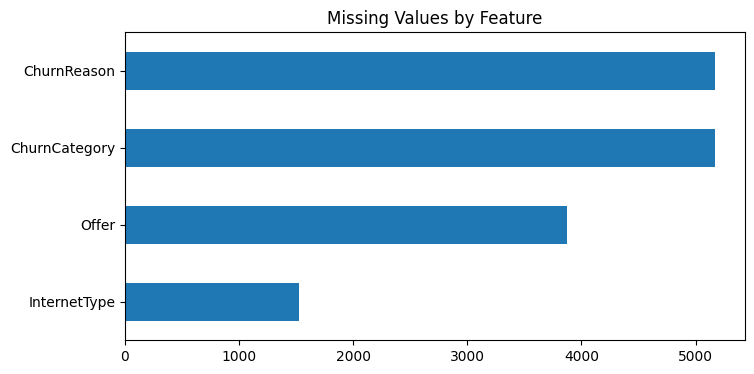

In [15]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Missing Values by Feature")
plt.show()

Missing InternetType values corresponded exactly to customers with no internet service.

In [11]:
df["InternetService"].value_counts()

,count
InternetService,
Yes,5517
No,1526


In [12]:
df["InternetType"].value_counts(dropna=False)

,count
InternetType,
Fiber Optic,3035
DSL,1652
NaN,1526
Cable,830


Missing Offer values were treated as "No Offer".

# **Churn Analysis**



## Satisfaction Score vs Churn

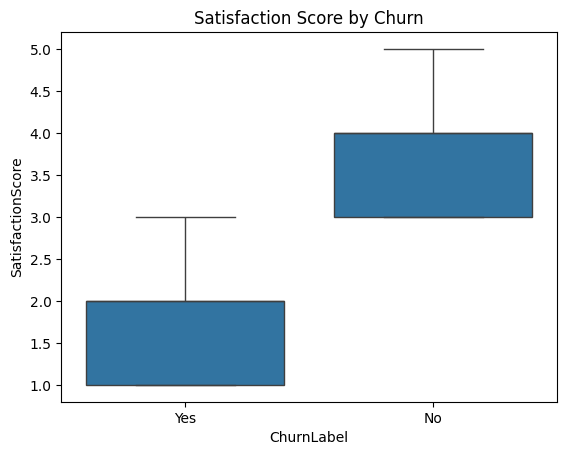

In [16]:
sns.boxplot(
    x="ChurnLabel",
    y="SatisfactionScore",
    data=df
)

plt.title("Satisfaction Score by Churn")
plt.show()

## Offer vs Churn

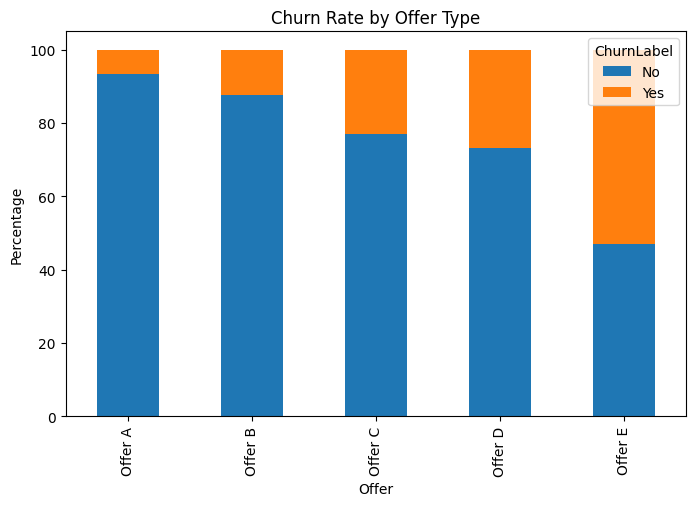

In [17]:
offer_churn = pd.crosstab(
    df["Offer"],
    df["ChurnLabel"],
    normalize="index"
) * 100

offer_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Offer Type")
plt.ylabel("Percentage")
plt.show()

## Contract Type vs Chun

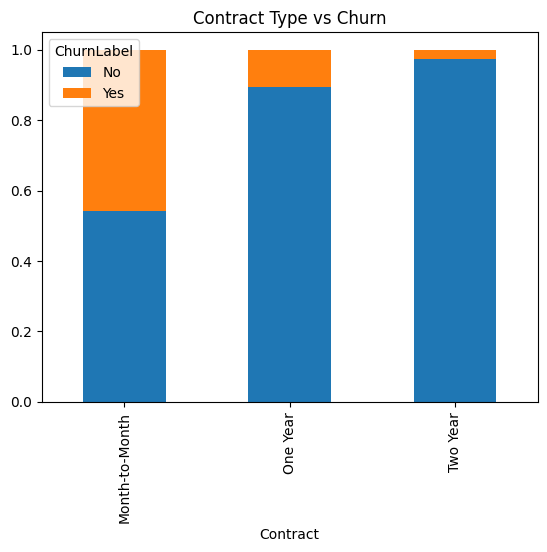

In [18]:
pd.crosstab(
    df["Contract"],
    df["ChurnLabel"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True
)

plt.title("Contract Type vs Churn")
plt.show()

# **Data Cleaning & Feature Selection**

# Features Removed:

- CustomerID
- Country
- State
- Quarter
- ChurnReason
- ChurnCategory
- CustomerStatus
- ChurnScore
- City
- ZipCode
- Latitude
- Longitude


These columns were removed because they were either:

- Identifiers
- Data leakage variables
- Non-informative variables
- High-cardinality variables introducing unnecessary noise


In [19]:
df_model = df.drop(
    columns=[
        "CustomerID",
        "Country",
        "State",
        "Quarter",
        "ChurnReason",
        "ChurnCategory",
        "CustomerStatus",
        "ChurnScore",
        "City",
        "ZipCode",
        "Latitude",
        "Longitude"
    ]
)




# **Data Preparation**

In [21]:
df_model["Offer"] = df_model["Offer"].fillna("No Offer")

df_model["InternetType"] = df_model["InternetType"].fillna("No Internet")


df_model.isnull().sum().sort_values(ascending=False)

,0
Gender,0
Age,0
Under30,0
SeniorCitizen,0
Married,0
Dependents,0
NumberofDependents,0
Population,0
ReferredaFriend,0
Number_of_Referrals,0


In [22]:
df_model["ChurnLabel"] = df_model["ChurnLabel"].map({
    "No": 0,
    "Yes": 1
})

df_model["ChurnLabel"].value_counts()


,count
ChurnLabel,
0,5174
1,1869


In [23]:
df_encoded = pd.get_dummies(
    df_model,
    drop_first=True
)

df_encoded.shape

df_encoded.dtypes.value_counts()

,count
bool,30
int64,10
float64,6


In [24]:
df_encoded.shape

(7043, 46)

# **Logistic Regression**

In [25]:
X = df_encoded.drop("ChurnLabel", axis=1)

y = df_encoded["ChurnLabel"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)



In [27]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))


Accuracy: 0.9616749467707594
[[1018   17]
 [  37  337]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.95      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [28]:
from sklearn.metrics import roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_proba)

np.float64(0.9920096101681779)

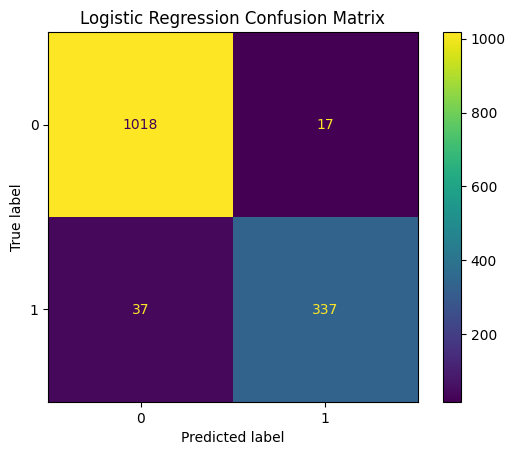

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [32]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)


,Feature,Coefficient
7,MonthlyCharge,0.916199
20,ReferredaFriend_Yes,0.670427
21,Offer_Offer A,0.487313
38,StreamingMusic_Yes,0.380526
1,NumberofDependents,0.337830
11,TotalLongDistanceCharges,0.272280
17,SeniorCitizen_Yes,0.229372
18,Married_Yes,0.219372
42,PaperlessBilling_Yes,0.189197
2,Population,0.179595


In [33]:
coef_df.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

,Feature,Coefficient
13,SatisfactionScore,-6.978743
3,Number_of_Referrals,-1.945897
32,OnlineSecurity_Yes,-1.281810
19,Dependents_Yes,-1.009922
4,TenureinMonths,-0.882691
41,Contract_Two Year,-0.864718
26,PhoneService_Yes,-0.367707
40,Contract_One Year,-0.352305
37,StreamingMovies_Yes,-0.286908
35,PremiumTechSupport_Yes,-0.280982


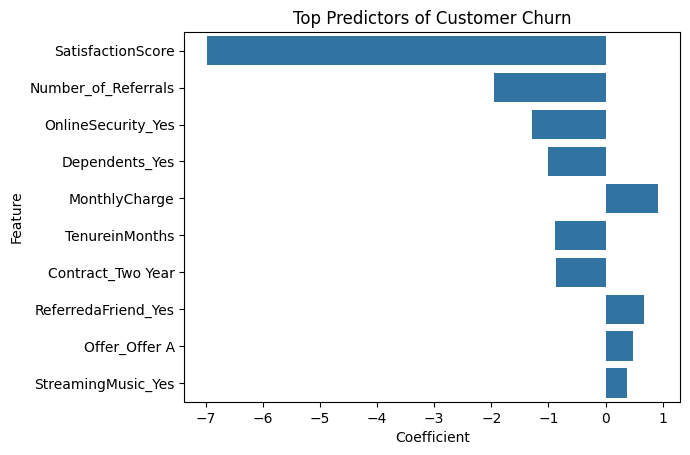

In [34]:
top_coef = coef_df.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
).head(10)

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=top_coef
)

plt.title("Top Predictors of Customer Churn")
plt.show()

# **Random Forest**

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)


rf_pred = rf_model.predict(X_test)


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

Accuracy: 0.9552874378992193
[[1025   10]
 [  53  321]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1035
           1       0.97      0.86      0.91       374

    accuracy                           0.96      1409
   macro avg       0.96      0.92      0.94      1409
weighted avg       0.96      0.96      0.95      1409

ROC-AUC: 0.984364101371774


In [36]:
comparison = pd.DataFrame({

"Model":["Logistic Regression","Random Forest"],

"Accuracy":[96.17,95.53],

"Recall":[90,86],

"ROC_AUC":[99.2,98.4]

})

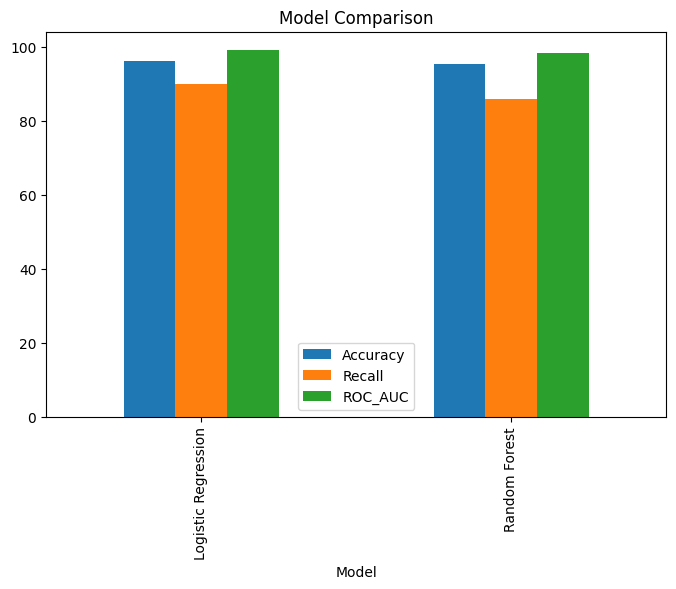

In [37]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.show()

## Key Findings

- Satisfaction Score was the strongest retention factor.
- Longer contract durations reduced churn risk.
- Higher monthly charges increased churn risk.
- Logistic Regression outperformed Random Forest in Recall and ROC-AUC.

Despite being the simpler algorithm, Logistic Regression achieved superior Recall and ROC-AUC performance.

This project demonstrated that careful data cleaning, feature selection, and business understanding can be more impactful than model complexity.

Final Performance:

Accuracy: 96.17%
Precision: 95%
Recall: 90%
F1 Score: 93%
ROC-AUC: 0.992